In [56]:
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

df = pd.read_csv("../user_movie_rates.csv")
df.head()

,user_id,movie_id,rating,datetime
0,1,1193,5,2000-12-31 22:12:40+00:00
1,1,661,3,2000-12-31 22:35:09+00:00
2,1,914,3,2000-12-31 22:32:48+00:00
3,1,3408,4,2000-12-31 22:04:35+00:00
4,1,2355,5,2001-01-06 23:38:11+00:00


In [57]:
print(df.columns)
print(df.shape)

Index(['user_id', 'movie_id', 'rating', 'datetime'], dtype='str')
(948367, 4)


In [58]:
df["rating"].value_counts().sort_index()

rating
1     52181
2    101962
3    248585
4    331604
5    214035
Name: count, dtype: int64

In [59]:
!pip install implicit

### Построение положительных взаимодействий

Все оценки, превышающие порог, интерпретируются как положительное взаимодействие пользователя с фильмом. Такой подход широко применяется в рекомендательных системах, поскольку implicit feedback лучше подходит для задач ранжирования.

### Фильтрация пользователей по числу взаимодействий

Пользователи с очень малым количеством взаимодействий содержат недостаточно информации для обучения модели.
Поэтому вводится параметр `min_pos`, задающий **минимальное количество положительных взаимодействий пользователя**.
Пользователи, у которых число взаимодействий меньше данного порога, удаляются из датасета. Это позволяет повысить качество обучения и уменьшить влияние шумовых данных.

In [60]:
from common.data_prep import build_edges, filter_users_min_pos

THRESHOLDS = [3.0, 4.0, 5.0]
MIN_POS_LIST = [5, 10, 20]
experiments = {}

for threshold in THRESHOLDS:
    edges_thr = build_edges(df, threshold=threshold)

    for min_pos in MIN_POS_LIST:
        edges = filter_users_min_pos(edges_thr, min_pos=min_pos)

        exp_name = f"thr_{threshold:.1f}_minpos_{min_pos}"
        experiments[exp_name] = {
            "threshold": threshold,
            "min_pos": min_pos,
            "edges": edges,
        }

        print(
            f"{exp_name}: "
            f"edges={len(edges)}, "
            f"users={edges['user_id'].nunique()}, "
            f"movies={edges['movie_id'].nunique()}"
        )


thr_3.0_minpos_5: edges=794223, users=6038, movies=3264
thr_3.0_minpos_10: edges=794183, users=6033, movies=3264
thr_3.0_minpos_20: edges=788215, users=5673, movies=3261
thr_4.0_minpos_5: edges=545628, users=6033, movies=3197
thr_4.0_minpos_10: edges=544897, users=5937, movies=3196
thr_4.0_minpos_20: edges=531904, users=5083, movies=3189
thr_5.0_minpos_5: edges=212898, users=5614, movies=2944
thr_5.0_minpos_10: edges=206814, users=4746, movies=2940
thr_5.0_minpos_20: edges=186161, users=3282, movies=2920


### Разделение данных на обучающую и тестовую выборки

Для оценки качества рекомендаций данные разделяются на обучающую и тестовую части.

Используется временное разделение (temporal split): последние `n` взаимодействий каждого пользователя помещаются в тестовую выборку, а остальные используются для обучения.
Такой подход имитирует реальный сценарий работы рекомендательной системы, в котором необходимо предсказывать будущие интересы пользователя на основе его прошлых действий.

In [61]:
import importlib
import common.split
importlib.reload(common.split)
from common.split import temporal_train_test_split
import pandas as pd

splits = {}

for exp_name, exp_data in experiments.items():
    edges = exp_data["edges"]
    train_df, test_df = temporal_train_test_split(
        edges,
        user_col="user_id",
        time_col="datetime",
        test_ratio=0.2,
        min_train=1,
        min_test=1,
    )

    splits[exp_name] = {
        "train": train_df,
        "test": test_df,
        "threshold": exp_data["threshold"],
        "min_pos": exp_data["min_pos"],
        "split_type": "temporal_80_20",
    }

    print(
        f"{exp_name}: "
        f"train={len(train_df)}, "
        f"test={len(test_df)}, "
        f"train_users={train_df['user_id'].nunique()}, "
        f"test_users={test_df['user_id'].nunique()}"
    )


thr_3.0_minpos_5: train=632944, test=161279, train_users=6038, test_users=6038
thr_3.0_minpos_10: train=632914, test=161269, train_users=6033, test_users=6033
thr_3.0_minpos_20: train=628284, test=159931, train_users=5673, test_users=5673
thr_4.0_minpos_5: train=434116, test=111512, train_users=6033, test_users=6033
thr_4.0_minpos_10: train=433568, test=111329, train_users=5937, test_users=5937
thr_4.0_minpos_20: train=423522, test=108382, train_users=5083, test_users=5083
thr_5.0_minpos_5: train=168107, test=44791, train_users=5614, test_users=5614
thr_5.0_minpos_10: train=163580, test=43234, train_users=4746, test_users=4746
thr_5.0_minpos_20: train=147627, test=38534, train_users=3282, test_users=3282


In [62]:
stats = []

for exp_name, split_data in splits.items():
    train_df = split_data["train"]
    test_df = split_data["test"]

    stats.append({
        "experiment": exp_name,
        "threshold": split_data["threshold"],
        "min_pos": split_data["min_pos"],
        "split_type": split_data["split_type"],
        "train_edges": len(train_df),
        "test_edges": len(test_df),
        "train_users": train_df["user_id"].nunique(),
        "test_users": test_df["user_id"].nunique(),
        "train_movies": train_df["movie_id"].nunique(),
        "test_movies": test_df["movie_id"].nunique(),
    })

stats_df = pd.DataFrame(stats).sort_values(
    ["threshold", "min_pos"]
).reset_index(drop=True)

stats_df


,experiment,threshold,min_pos,split_type,train_edges,test_edges,train_users,test_users,train_movies,test_movies
0,thr_3.0_minpos_5,3.0,5,temporal_80_20,632944,161279,6038,6038,3221,3142
1,thr_3.0_minpos_10,3.0,10,temporal_80_20,632914,161269,6033,6033,3221,3142
2,thr_3.0_minpos_20,3.0,20,temporal_80_20,628284,159931,5673,5673,3219,3140
3,thr_4.0_minpos_5,4.0,5,temporal_80_20,434116,111512,6033,6033,3135,3027
4,thr_4.0_minpos_10,4.0,10,temporal_80_20,433568,111329,5937,5937,3134,3027
5,thr_4.0_minpos_20,4.0,20,temporal_80_20,423522,108382,5083,5083,3126,3020
6,thr_5.0_minpos_5,5.0,5,temporal_80_20,168107,44791,5614,5614,2817,2571
7,thr_5.0_minpos_10,5.0,10,temporal_80_20,163580,43234,4746,4746,2810,2560
8,thr_5.0_minpos_20,5.0,20,temporal_80_20,147627,38534,3282,3282,2784,2516


In [63]:
exp_name = "thr_3.0_minpos_5"

train_df = splits[exp_name]["train"]
test_df = splits[exp_name]["test"]

train_df.head(), test_df.head()


(   user_id  movie_id                  datetime
 0        1      3186 2000-12-31 22:00:19+00:00
 1        1      1270 2000-12-31 22:00:55+00:00
 2        1      1721 2000-12-31 22:00:55+00:00
 3        1      1022 2000-12-31 22:00:55+00:00
 4        1      2340 2000-12-31 22:01:43+00:00,
    user_id  movie_id                  datetime
 0        1       595 2001-01-06 23:37:48+00:00
 1        1      2687 2001-01-06 23:37:48+00:00
 2        1       745 2001-01-06 23:37:48+00:00
 3        1       588 2001-01-06 23:37:48+00:00
 4        1         1 2001-01-06 23:37:48+00:00)

### Индексация пользователей и фильмов

Модели факторизации матриц работают с числовыми индексами, а не с исходными идентификаторами пользователей и фильмов.

Поэтому создаются специальные отображения:

- `user2idx` — отображение `user_id` -> индекс строки матрицы
- `idx2user` — обратное отображение индекса в `user_id`
- `item2idx` — отображение `movie_id` -> индекс столбца матрицы
- `idx2item` — обратное отображение индекса в `movie_id`

Эти структуры позволяют эффективно работать с матрицей взаимодействий.

In [64]:
from common.indexing import build_index_maps, build_interaction_matrix

matrices = {}

for exp_name, split_data in splits.items():
    train_df = split_data["train"]
    test_df = split_data["test"]

    user2idx, idx2user, item2idx, idx2item = build_index_maps(train_df)
    X = build_interaction_matrix(train_df, user2idx, item2idx)

    matrices[exp_name] = {
        "X": X,
        "user2idx": user2idx,
        "idx2user": idx2user,
        "item2idx": item2idx,
        "idx2item": idx2item,
        "train": train_df,
        "test": test_df,
        "threshold": split_data["threshold"],
        "min_pos": split_data["min_pos"],
        "split_type": split_data["split_type"],
    }

    print(
        f"{exp_name}: "
        f"X.shape={X.shape}, nnz={X.nnz}"
    )


thr_3.0_minpos_5: X.shape=(6038, 3221), nnz=632944
thr_3.0_minpos_10: X.shape=(6033, 3221), nnz=632914
thr_3.0_minpos_20: X.shape=(5673, 3219), nnz=628284
thr_4.0_minpos_5: X.shape=(6033, 3135), nnz=434116
thr_4.0_minpos_10: X.shape=(5937, 3134), nnz=433568
thr_4.0_minpos_20: X.shape=(5083, 3126), nnz=423522
thr_5.0_minpos_5: X.shape=(5614, 2817), nnz=168107
thr_5.0_minpos_10: X.shape=(4746, 2810), nnz=163580
thr_5.0_minpos_20: X.shape=(3282, 2784), nnz=147627


In [65]:
exp_name = "thr_3.0_minpos_5"

bundle = matrices[exp_name]

X = bundle["X"]
train_df = bundle["train"]
test_df = bundle["test"]
user2idx = bundle["user2idx"]
idx2item = bundle["idx2item"]


### Обучение модели факторизации матриц

Для построения рекомендательной модели используется алгоритм Alternating Least Squares (ALS) для неявной обратной связи.

Метод факторизации матриц предполагает, что пользователи и фильмы могут быть представлены в виде векторов в скрытом (латентном) пространстве.
Каждому пользователю соответствует вектор предпочтений, а каждому фильму — вектор характеристик.
Релевантность фильма пользователю определяется скалярным произведением этих векторов:

Алгоритм ALS итеративно оптимизирует эти векторы, минимизируя ошибку между наблюдаемыми и предсказанными взаимодействиями.

In [66]:
from implicit.als import AlternatingLeastSquares


def train_mf_als(
        user_item_matrix,
        factors: int = 64,
        regularization: float = 0.01,
        iterations: int = 20,
        alpha: float = 10.0,
        random_state: int = 42,
):
    model = AlternatingLeastSquares(
        factors=factors,
        regularization=regularization,
        iterations=iterations,
        random_state=random_state,
    )

    user_item_conf = (user_item_matrix * alpha).tocsr()
    model.fit(user_item_conf)

    return model

/Users/alexandro/DataspellProjects/recommend-system/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [67]:
mf_model = train_mf_als(
    user_item_matrix=X,
    factors=64,
    regularization=0.01,
    iterations=20,
    alpha=10.0,
    random_state=42,
)

print("X.shape:", X.shape)
print("mf_model.user_factors.shape:", mf_model.user_factors.shape)
print("mf_model.item_factors.shape:", mf_model.item_factors.shape)

100%|██████████| 20/20 [00:02<00:00,  8.48it/s]

X.shape: (6038, 3221)
mf_model.user_factors.shape: (6038, 64)
mf_model.item_factors.shape: (3221, 64)


In [68]:
user_id = test_df["user_id"].iloc[0]
user_idx = user2idx[user_id]

rec_item_indices, rec_scores = mf_model.recommend(
    userid=user_idx,
    user_items=X[user_idx],
    N=10,
    filter_already_liked_items=True,
)

recommended_movie_ids = [idx2item[i] for i in rec_item_indices]
recommended_movie_ids

[np.int64(2858),
 np.int64(1),
 np.int64(318),
 np.int64(593),
 np.int64(595),
 np.int64(2087),
 np.int64(1198),
 np.int64(1704),
 np.int64(364),
 np.int64(2078)]

In [69]:
user_test_movies = test_df.loc[test_df["user_id"] == user_id, "movie_id"].tolist()

print("Recommended:", recommended_movie_ids)
print("Test movies:", user_test_movies)
print("Hits:", set(recommended_movie_ids) & set(user_test_movies))

Recommended: [np.int64(2858), np.int64(1), np.int64(318), np.int64(593), np.int64(595), np.int64(2087), np.int64(1198), np.int64(1704), np.int64(364), np.int64(2078)]
Test movies: [595, 2687, 745, 588, 1, 2355, 2294, 783, 1566, 1907, 48]
Hits: {np.int64(1), np.int64(595)}


In [70]:
def recommend_mf(model, X, user2idx, idx2item, users, k=10):
    recommendations = {}

    for user_id in users:
        if user_id not in user2idx:
            continue

        user_idx = user2idx[user_id]

        rec_item_indices, rec_scores = model.recommend(
            userid=user_idx,
            user_items=X[user_idx],
            N=k,
            filter_already_liked_items=True,
        )

        recommendations[user_id] = [idx2item[i] for i in rec_item_indices]

    return recommendations

In [71]:
from common.eval import build_user_item_dict

test_user_items = build_user_item_dict(test_df)
test_users = list(test_user_items.keys())

In [72]:
recommendations = recommend_mf(
    model=mf_model,
    X=X,
    user2idx=user2idx,
    idx2item=idx2item,
    users=test_users,
    k=10,
)

In [73]:
from common.eval import evaluate_ranking

metrics = evaluate_ranking(
    recommendations=recommendations,
    ground_truth=test_user_items,
    k=10,
)

metrics

{'precision': np.float64(0.0971844981782047),
 'recall': np.float64(0.07270946087455406),
 'map': np.float64(0.04880924647593877),
 'ndcg': np.float64(0.11057819757261106),
 'mrr': np.float64(0.22031479203142001),
 'hitrate': np.float64(0.5457105001656177)}

In [74]:
mf_results = []

for exp_name, bundle in matrices.items():
    X = bundle["X"]
    test_df = bundle["test"]
    user2idx = bundle["user2idx"]
    idx2item = bundle["idx2item"]

    mf_model = train_mf_als(
        user_item_matrix=X,
        factors=64,
        regularization=0.01,
        iterations=20,
        alpha=10.0,
        random_state=42,
    )

    test_user_items = build_user_item_dict(test_df)

    recommendations = recommend_mf(
        model=mf_model,
        X=X,
        user2idx=user2idx,
        idx2item=idx2item,
        users=list(test_user_items.keys()),
        k=10,
    )

    metrics = evaluate_ranking(
        recommendations=recommendations,
        ground_truth=test_user_items,
        k=10,
    )

    mf_results.append({
        "experiment": exp_name,
        "split_type": bundle["split_type"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "map": metrics["map"],
        "ndcg": metrics["ndcg"],
        "mrr": metrics["mrr"],
        "hitrate": metrics["hitrate"],
        "train_edges": bundle["train"].shape[0],
        "test_edges": bundle["test"].shape[0],
        "graph_nodes": X.shape[0] + X.shape[1],
    })


100%|██████████| 20/20 [00:00<00:00, 22.13it/s]


In [75]:
mf_results_df = pd.DataFrame(mf_results)
mf_results_df

,experiment,split_type,precision,recall,map,ndcg,mrr,hitrate,train_edges,test_edges,graph_nodes
0,thr_3.0_minpos_5,temporal_80_20,0.097184,0.072709,0.048809,0.110578,0.220315,0.545711,632944,161279,9259
1,thr_3.0_minpos_10,temporal_80_20,0.098028,0.072849,0.049364,0.110981,0.218359,0.550307,632914,161269,9254
2,thr_3.0_minpos_20,temporal_80_20,0.098026,0.064116,0.046947,0.107853,0.220258,0.544685,628284,159931,8892
3,thr_4.0_minpos_5,temporal_80_20,0.079231,0.078017,0.043414,0.098314,0.199174,0.500083,434116,111512,9168
4,thr_4.0_minpos_10,temporal_80_20,0.080310,0.075947,0.042844,0.097120,0.192727,0.496210,433568,111329,9071
5,thr_4.0_minpos_20,temporal_80_20,0.084320,0.063811,0.040403,0.095459,0.203812,0.512886,423522,108382,8209
6,thr_5.0_minpos_5,temporal_80_20,0.049982,0.097620,0.039967,0.081898,0.141350,0.374955,168107,44791,8431
7,thr_5.0_minpos_10,temporal_80_20,0.055162,0.087684,0.036618,0.080871,0.154744,0.411715,163580,43234,7556
8,thr_5.0_minpos_20,temporal_80_20,0.058988,0.064871,0.029432,0.072468,0.160451,0.422608,147627,38534,6066


In [76]:
import matplotlib.pyplot as plt

df = mf_results_df.copy()

df["threshold"] = df["experiment"].str.extract(r"thr_(\d+\.\d+)").astype(float)
df["min_pos"] = df["experiment"].str.extract(r"minpos_(\d+)").astype(int)

numeric_cols = [
    "precision", "recall", "map", "ndcg", "mrr", "hitrate",
    "train_edges", "test_edges", "graph_nodes"
]

for c in numeric_cols:
    df[c] = df[c].astype(float)


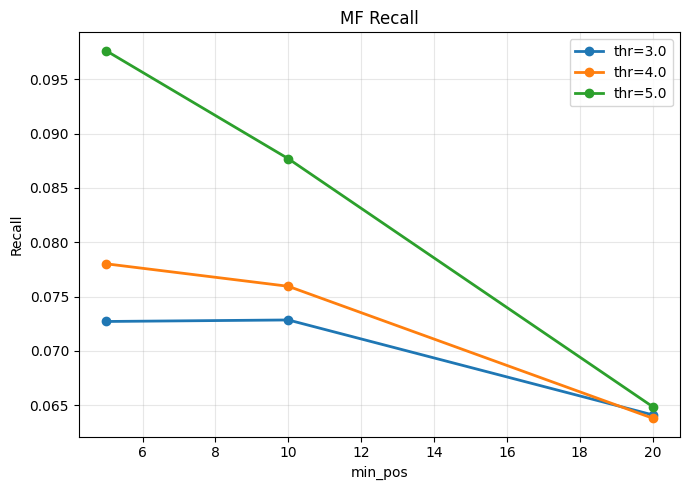

In [77]:
plt.figure(figsize=(7, 5))

for thr in sorted(df["threshold"].unique()):
    tmp = df[df["threshold"] == thr].sort_values("min_pos")

    plt.plot(
        tmp["min_pos"],
        tmp["recall"],
        marker="o",
        linewidth=2,
        label=f"thr={thr}"
    )

plt.title("MF Recall")
plt.xlabel("min_pos")
plt.ylabel("Recall")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


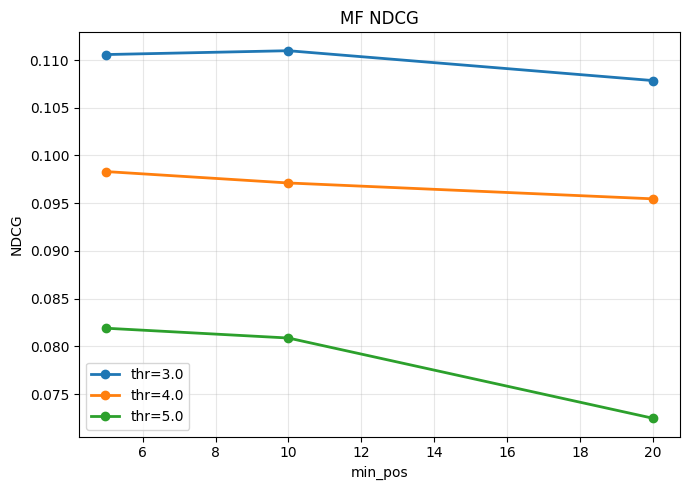

In [78]:
plt.figure(figsize=(7, 5))

for thr in sorted(df["threshold"].unique()):
    tmp = df[df["threshold"] == thr].sort_values("min_pos")

    plt.plot(
        tmp["min_pos"],
        tmp["ndcg"],
        marker="o",
        linewidth=2,
        label=f"thr={thr}"
    )

plt.title("MF NDCG")
plt.xlabel("min_pos")
plt.ylabel("NDCG")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


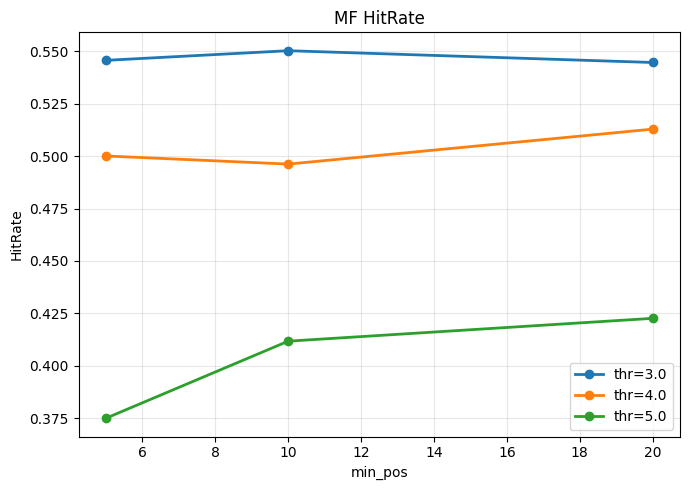

In [79]:
plt.figure(figsize=(7, 5))

for thr in sorted(df["threshold"].unique()):
    tmp = df[df["threshold"] == thr].sort_values("min_pos")

    plt.plot(
        tmp["min_pos"],
        tmp["hitrate"],
        marker="o",
        linewidth=2,
        label=f"thr={thr}"
    )

plt.title("MF HitRate")
plt.xlabel("min_pos")
plt.ylabel("HitRate")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [80]:
FACTORS_LIST = [64, 128, 256]
REG_LIST = [0.01, 0.05, 0.1]
ALPHA_LIST = [5, 10, 20, 40]
ITER_LIST = [20, 30, 40]

USE_BM25_LIST = [False, True]
BM25_K1_LIST = [10, 50, 100]
BM25_B_LIST = [0.5, 0.8, 1.0]

In [81]:
mf_tuning_results = []

for exp_name, bundle in matrices.items():
    X = bundle["X"]
    test_df = bundle["test"]
    user2idx = bundle["user2idx"]
    idx2item = bundle["idx2item"]

    test_user_items = build_user_item_dict(test_df)
    test_users = list(test_user_items.keys())

    for factors in FACTORS_LIST:
        for reg in REG_LIST:
            for alpha in ALPHA_LIST:
                for n_iter in ITER_LIST:
                    try:
                        mf_model = train_mf_als(
                            user_item_matrix=X,
                            factors=factors,
                            regularization=reg,
                            iterations=n_iter,
                            alpha=alpha,
                            random_state=42,
                        )

                        recommendations = recommend_mf(
                            model=mf_model,
                            X=X,
                            user2idx=user2idx,
                            idx2item=idx2item,
                            users=test_users,
                            k=10,
                        )

                        metrics = evaluate_ranking(
                            recommendations=recommendations,
                            ground_truth=test_user_items,
                            k=10,
                        )

                        mf_tuning_results.append({
                            "experiment": exp_name,
                            "split_type": bundle["split_type"],
                            "factors": factors,
                            "regularization": reg,
                            "alpha": alpha,
                            "iterations": n_iter,
                            "precision": metrics["precision"],
                            "recall": metrics["recall"],
                            "map": metrics["map"],
                            "ndcg": metrics["ndcg"],
                            "mrr": metrics["mrr"],
                            "hitrate": metrics["hitrate"],
                            "train_edges": bundle["train"].shape[0],
                            "test_edges": bundle["test"].shape[0],
                            "graph_nodes": X.shape[0] + X.shape[1],
                        })
                    except Exception as e:
                        print(
                            f"[ERROR] exp={exp_name}, factors={factors}, reg={reg}, alpha={alpha}, it={n_iter}: {e}"
                        )


100%|██████████| 40/40 [00:06<00:00,  6.52it/s]


In [82]:
mf_tuning_df = pd.DataFrame(mf_tuning_results)
mf_tuning_df.sort_values(["recall", "ndcg"], ascending=False)

,experiment,split_type,factors,regularization,alpha,iterations,precision,recall,map,ndcg,mrr,hitrate,train_edges,test_edges,graph_nodes
663,thr_5.0_minpos_5,temporal_80_20,64,0.05,10,20,0.050641,0.099712,0.039947,0.082481,0.141390,0.382437,168107,44791,8431
675,thr_5.0_minpos_5,temporal_80_20,64,0.10,10,20,0.050730,0.099319,0.040013,0.082544,0.141798,0.381190,168107,44791,8431
653,thr_5.0_minpos_5,temporal_80_20,64,0.01,10,40,0.050588,0.098933,0.040404,0.082658,0.141636,0.379230,168107,44791,8431
672,thr_5.0_minpos_5,temporal_80_20,64,0.10,5,20,0.050392,0.098864,0.040990,0.083370,0.145286,0.379765,168107,44791,8431
660,thr_5.0_minpos_5,temporal_80_20,64,0.05,5,20,0.050552,0.098697,0.040946,0.083381,0.145029,0.381012,168107,44791,8431
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
946,thr_5.0_minpos_20,temporal_80_20,256,0.01,40,30,0.042139,0.045284,0.020049,0.051626,0.119961,0.335161,147627,38534,6066
955,thr_5.0_minpos_20,temporal_80_20,256,0.05,20,30,0.042322,0.045262,0.019958,0.051696,0.120398,0.337294,147627,38534,6066
939,thr_5.0_minpos_20,temporal_80_20,256,0.01,10,20,0.041926,0.045194,0.019980,0.051490,0.120175,0.334857,147627,38534,6066
947,thr_5.0_minpos_20,temporal_80_20,256,0.01,40,40,0.042017,0.045024,0.019859,0.051459,0.120619,0.333333,147627,38534,6066


In [83]:
df = mf_tuning_df.copy()

df["threshold"] = df["experiment"].str.extract(r"thr_(\d+\.\d+)").astype(float)
df["min_pos"] = df["experiment"].str.extract(r"minpos_(\d+)").astype(int)

df = df.sort_values(
    ["experiment", "factors", "regularization", "alpha", "iterations"]
).reset_index(drop=True)

df.head()


,experiment,split_type,factors,regularization,alpha,iterations,precision,recall,map,ndcg,mrr,hitrate,train_edges,test_edges,graph_nodes,threshold,min_pos
0,thr_3.0_minpos_10,temporal_80_20,64,0.01,5,20,0.103066,0.075556,0.053087,0.116933,0.227686,0.560252,632914,161269,9254,3.0,10
1,thr_3.0_minpos_10,temporal_80_20,64,0.01,5,30,0.102536,0.074989,0.052758,0.116467,0.228663,0.559755,632914,161269,9254,3.0,10
2,thr_3.0_minpos_10,temporal_80_20,64,0.01,5,40,0.102387,0.074875,0.052631,0.116363,0.228742,0.558760,632914,161269,9254,3.0,10
3,thr_3.0_minpos_10,temporal_80_20,64,0.01,10,20,0.098028,0.072849,0.049364,0.110981,0.218359,0.550307,632914,161269,9254,3.0,10
4,thr_3.0_minpos_10,temporal_80_20,64,0.01,10,30,0.097713,0.072820,0.049046,0.110645,0.218805,0.551633,632914,161269,9254,3.0,10


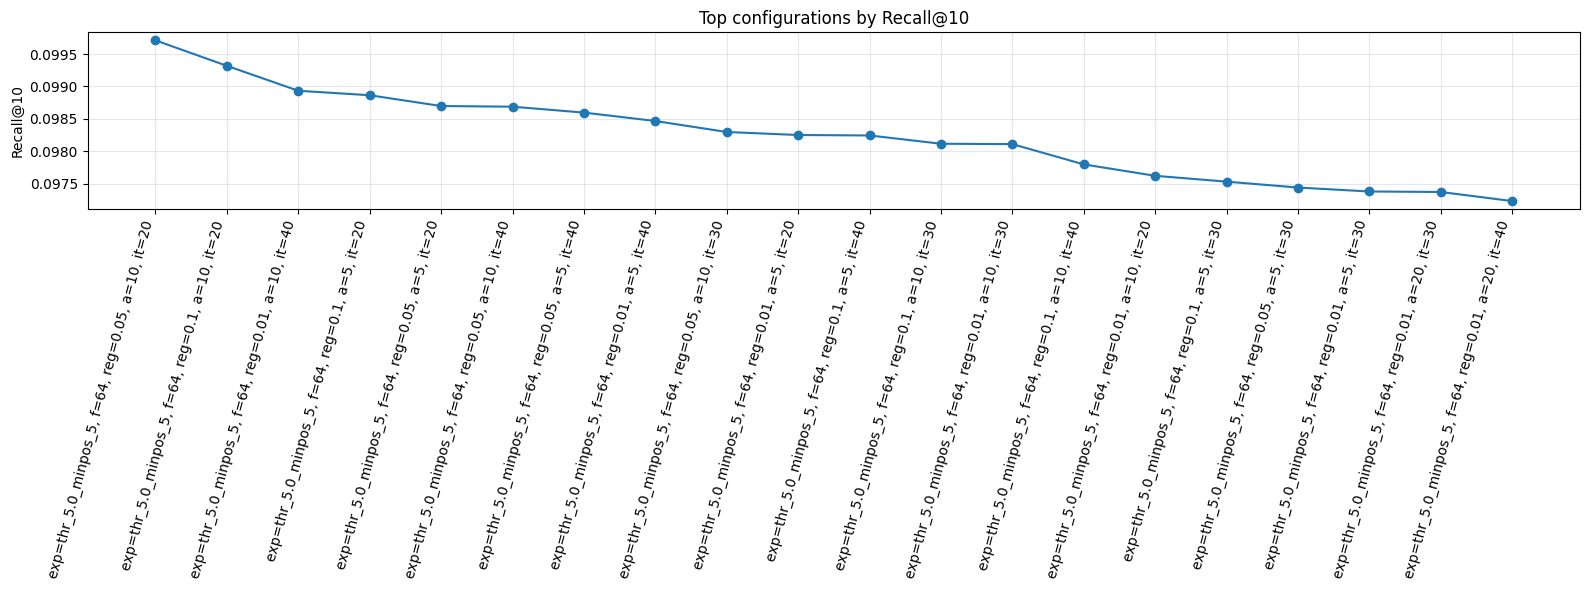

In [84]:
top_n = 20

top_df = df.sort_values(["recall", "ndcg"], ascending=False).head(top_n).copy()

top_df["label"] = (
        "exp=" + top_df["experiment"]
        + ", f=" + top_df["factors"].astype(str)
        + ", reg=" + top_df["regularization"].astype(str)
        + ", a=" + top_df["alpha"].astype(str)
        + ", it=" + top_df["iterations"].astype(str)
)

plt.figure(figsize=(16, 6))
plt.plot(top_df["label"], top_df["recall"], marker="o")
plt.xticks(rotation=75, ha="right")
plt.ylabel("Recall@10")
plt.title("Top configurations by Recall@10")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


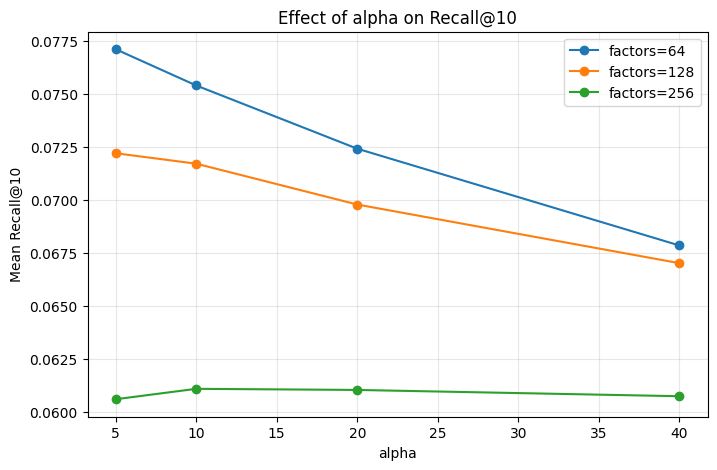

In [85]:
plt.figure(figsize=(8, 5))

for factors in sorted(df["factors"].unique()):
    tmp = (
        df.groupby(["alpha", "factors"], as_index=False)["recall"]
        .mean()
    )
    tmp = tmp[tmp["factors"] == factors].sort_values("alpha")

    plt.plot(tmp["alpha"], tmp["recall"], marker="o", label=f"factors={factors}")

plt.xlabel("alpha")
plt.ylabel("Mean Recall@10")
plt.title("Effect of alpha on Recall@10")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

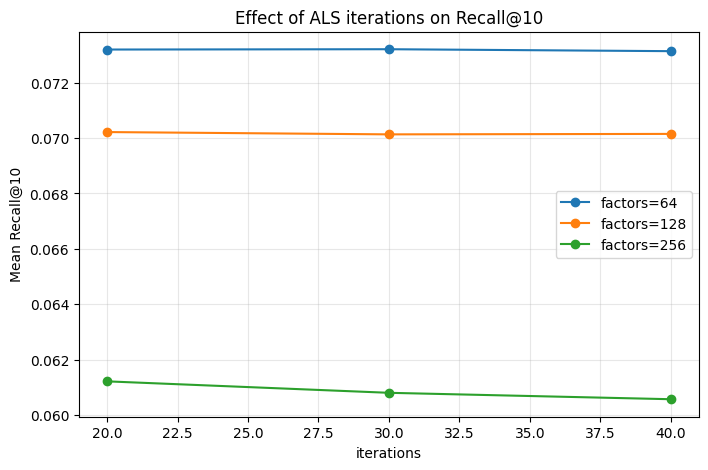

In [86]:
plt.figure(figsize=(8, 5))

for factors in sorted(df["factors"].unique()):
    tmp = (
        df.groupby(["iterations", "factors"], as_index=False)["recall"]
        .mean()
    )
    tmp = tmp[tmp["factors"] == factors].sort_values("iterations")

    plt.plot(tmp["iterations"], tmp["recall"], marker="o", label=f"factors={factors}")

plt.xlabel("iterations")
plt.ylabel("Mean Recall@10")
plt.title("Effect of ALS iterations on Recall@10")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [88]:
K_LIST = [5, 10, 20]
mf_tuning_results = []

for exp_name, bundle in matrices.items():
    X = bundle["X"]
    test_df = bundle["test"]
    user2idx = bundle["user2idx"]
    idx2item = bundle["idx2item"]

    test_user_items = build_user_item_dict(test_df)
    test_users = list(test_user_items.keys())
    for k in K_LIST:
        try:
            mf_model = train_mf_als(
                user_item_matrix=X,
                factors=64,
                regularization=0.05,
                iterations=20,
                alpha=5,
                random_state=42,
            )

            recommendations = recommend_mf(
                model=mf_model,
                X=X,
                user2idx=user2idx,
                idx2item=idx2item,
                users=test_users,
                k=k,
            )

            metrics = evaluate_ranking(
                recommendations=recommendations,
                ground_truth=test_user_items,
                k=k,
            )

            mf_tuning_results.append({
                "experiment": exp_name,
                "split_type": bundle["split_type"],
                "k": k,
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "map": metrics["map"],
                "ndcg": metrics["ndcg"],
                "mrr": metrics["mrr"],
                "hitrate": metrics["hitrate"],
            })
        except Exception as e:
            print(f"[ERROR] exp={exp_name}, k={k}: {e}")


100%|██████████| 20/20 [00:00<00:00, 22.16it/s]


In [89]:
mf_tuning_df = pd.DataFrame(mf_tuning_results)
mf_tuning_df

,experiment,split_type,k,precision,recall,map,ndcg,mrr,hitrate
0,thr_3.0_minpos_5,temporal_80_20,5,0.107420,0.039695,0.063445,0.110647,0.205816,0.375290
1,thr_3.0_minpos_5,temporal_80_20,10,0.103511,0.075327,0.053310,0.117471,0.230304,0.559622
2,thr_3.0_minpos_5,temporal_80_20,20,0.095214,0.133573,0.051292,0.133944,0.243151,0.743789
3,thr_3.0_minpos_10,temporal_80_20,5,0.108105,0.039901,0.063553,0.110685,0.204199,0.377258
4,thr_3.0_minpos_10,temporal_80_20,10,0.102868,0.074648,0.053185,0.116772,0.228088,0.557103
5,thr_3.0_minpos_10,temporal_80_20,20,0.095525,0.133360,0.051274,0.133867,0.241261,0.746229
6,thr_3.0_minpos_20,temporal_80_20,5,0.109501,0.035364,0.064795,0.112428,0.211014,0.379693
7,thr_3.0_minpos_20,temporal_80_20,10,0.103772,0.066854,0.051779,0.115234,0.234670,0.558435
8,thr_3.0_minpos_20,temporal_80_20,20,0.097206,0.121409,0.048717,0.130431,0.247746,0.746166
9,thr_4.0_minpos_5,temporal_80_20,5,0.088381,0.044541,0.052607,0.094243,0.179717,0.335322


In [95]:
mf_tuning_df["threshold"] = mf_tuning_df["experiment"].str.extract(r"thr_(\d+\.\d+)").astype(float)
mf_tuning_df["min_pos"] = mf_tuning_df["experiment"].str.extract(r"minpos_(\d+)").astype(int)

max_recall_per_k = mf_tuning_df.loc[
    mf_tuning_df.groupby("k")["recall"].idxmax()
].sort_values("k")[["threshold", "min_pos", "k", "recall"]]

max_recall_per_k

,threshold,min_pos,k,recall
18,5.0,5,5,0.058066
19,5.0,5,10,0.098697
20,5.0,5,20,0.160414


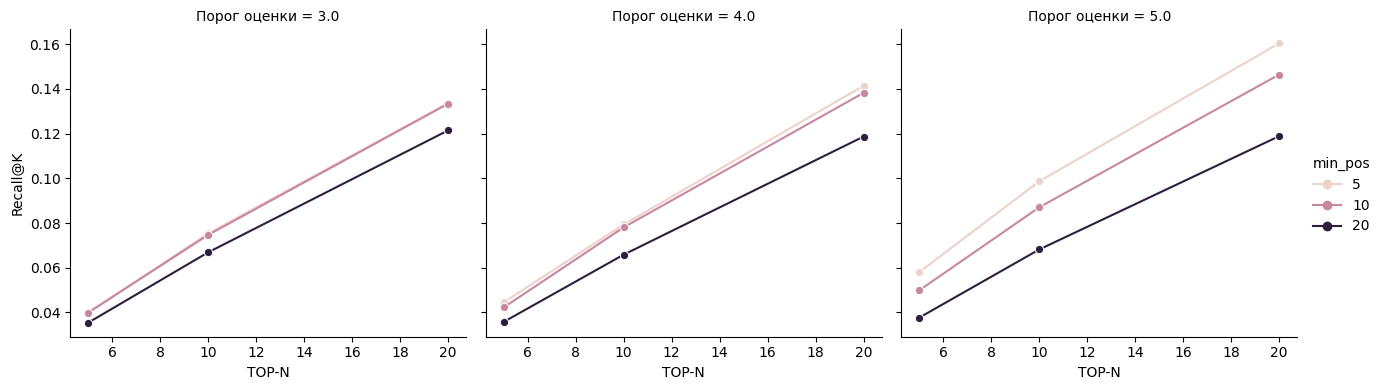

In [98]:
import seaborn as sns

g = sns.relplot(
    data=mf_tuning_df,
    x="k",
    y="recall",
    hue="min_pos",
    col="threshold",
    kind="line",
    marker="o",
    height=4,
    aspect=1.1
)

g.set_axis_labels("TOP-N", "Recall@K")
g.set_titles("Порог оценки = {col_name}")
plt.show()

In [99]:
max_ndcg_per_k = mf_tuning_df.loc[
    mf_tuning_df.groupby("k")["ndcg"].idxmax()
].sort_values("k")[["threshold", "min_pos", "k", "ndcg"]]

max_ndcg_per_k

,threshold,min_pos,k,ndcg
6,3.0,20,5,0.112428
1,3.0,5,10,0.117471
2,3.0,5,20,0.133944


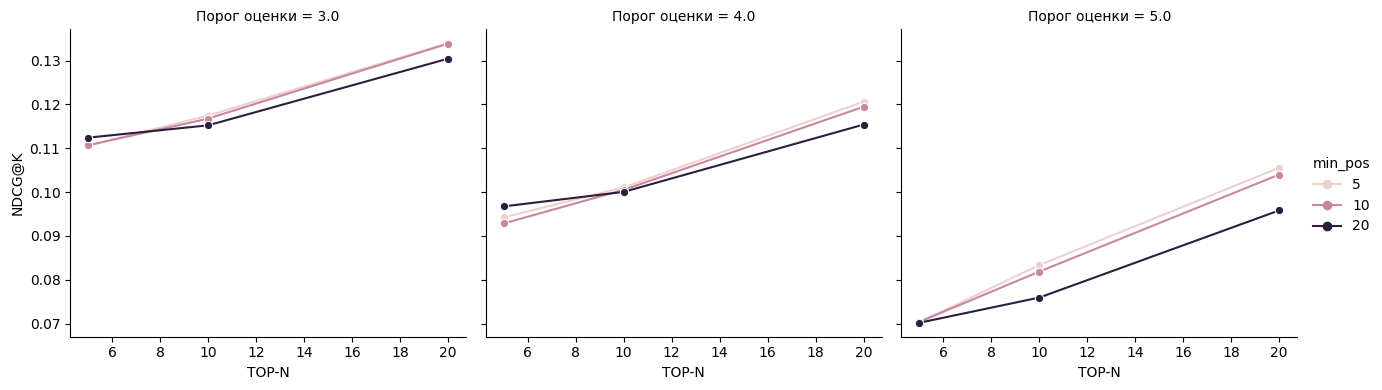

In [100]:
g = sns.relplot(
    data=mf_tuning_df,
    x="k",
    y="ndcg",
    hue="min_pos",
    col="threshold",
    kind="line",
    marker="o",
    height=4,
    aspect=1.1
)

g.set_axis_labels("TOP-N", "NDCG@K")
g.set_titles("Порог оценки = {col_name}")
plt.show()

In [101]:
max_hitrate_per_k = mf_tuning_df.loc[
    mf_tuning_df.groupby("k")["ndcg"].idxmax()
].sort_values("k")[["threshold", "min_pos", "k", "hitrate"]]

max_hitrate_per_k

,threshold,min_pos,k,hitrate
6,3.0,20,5,0.379693
1,3.0,5,10,0.559622
2,3.0,5,20,0.743789


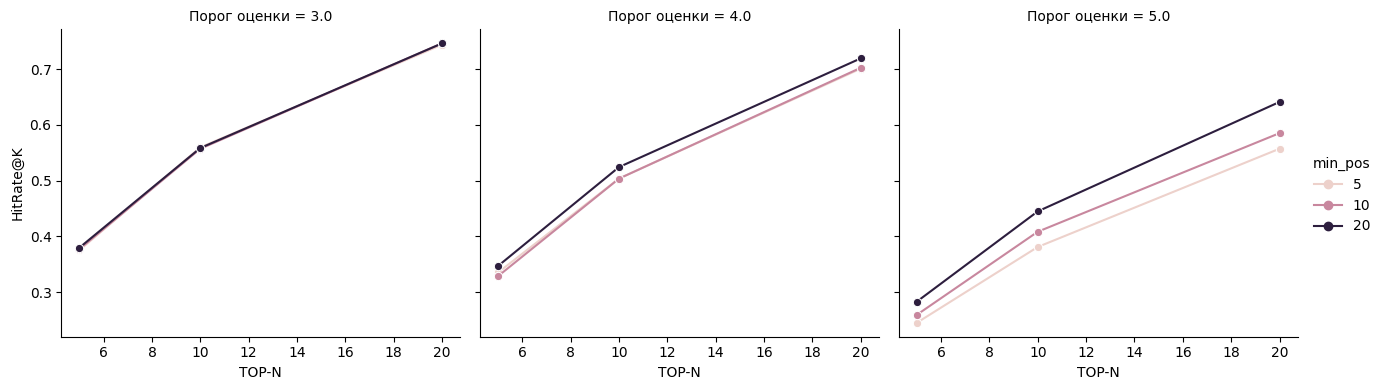

In [102]:
g = sns.relplot(
    data=mf_tuning_df,
    x="k",
    y="hitrate",
    hue="min_pos",
    col="threshold",
    kind="line",
    marker="o",
    height=4,
    aspect=1.1
)

g.set_axis_labels("TOP-N", "HitRate@K")
g.set_titles("Порог оценки = {col_name}")
plt.show()